In [7]:
import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare, wilcoxon
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
METRIC = "mse"

## Test Functions

In [3]:
def overall_friedman_test(results_df, metric=METRIC):
    pivot = results_df.groupby(["dataset", "arch"])[metric].mean().unstack()
    archs = pivot.columns.tolist()

    stat, p = friedmanchisquare(*[pivot[a] for a in archs])
    print(f"=== Overall Friedman test ({metric}) ===")
    print(pivot)
    print(f"\nFriedman stat={stat:.4f}, p={p:.4f}")
    if p < 0.05:
        print("Significant difference detected among architectures overall.\n")
    else:
        print("No significant overall difference detected among architectures.\n")
    return pivot, stat, p

In [ ]:
def pairwise_wilcoxon(pivot, alpha=0.05):
    archs = pivot.columns.tolist()
    pairs = list(combinations(archs, 2))
    n_comparisons = len(pairs)
    # Bonferreni correction
    corrected_alpha = alpha / n_comparisons

    print(f"=== Pairwise Wilcoxon tests (Bonferroni-corrected alpha={corrected_alpha:.4f}) ===")
    results = []
    for a, b in pairs:
        stat, p = wilcoxon(pivot[a], pivot[b])
        significant = p < corrected_alpha
        winner = a if pivot[a].mean() < pivot[b].mean() else b
        print(f"{a} vs {b}: stat={stat:.4f}, p={p:.4f} "
              f"{'** significant **' if significant else '(not significant)'} "
              f"-> lower mean: {winner}")
        results.append({"arch_a": a, "arch_b": b, "stat": stat, "p": p,
                         "significant": significant, "lower_mean_arch": winner})
    return pd.DataFrame(results)

In [ ]:
def per_dataset_tests(results_df, metric=METRIC, alpha=0.05):
    print(f"\n=== Per-dataset architecture comparison ({metric}) ===")
    all_results = []

    for dataset in results_df["dataset"].unique():
        sub = results_df[results_df["dataset"] == dataset]
        pivot_folds = sub.pivot(index="fold", columns="arch", values=metric)
        archs = pivot_folds.columns.tolist()

        print(f"\n--- {dataset} ---")
        print(pivot_folds.mean().sort_values())

        stat, p = friedmanchisquare(*[pivot_folds[a] for a in archs])
        print(f"Friedman: stat={stat:.4f}, p={p:.4f}")

        pairs = list(combinations(archs, 2))
        corrected_alpha = alpha / len(pairs)
        for a, b in pairs:
            w_stat, w_p = wilcoxon(pivot_folds[a], pivot_folds[b])
            sig = w_p < corrected_alpha
            winner = a if pivot_folds[a].mean() < pivot_folds[b].mean() else b
            print(f"  {a} vs {b}: p={w_p:.4f} {'**' if sig else ''} -> {winner}")
            all_results.append({
                "dataset": dataset, "arch_a": a, "arch_b": b,
                "p": w_p, "significant": sig, "winner": winner if sig else "tie",
            })

    return pd.DataFrame(all_results)

### LOPO

In [20]:
def lopo_friedman_test(lopo_df, metric=METRIC):
    pivot = lopo_df.pivot(index="held_out_profile", columns="arch", values=metric)
    archs = pivot.columns.tolist()

    print("=== LOPO Friedman test (motor-temp) ===")
    print(pivot)

    stat, p = friedmanchisquare(*[pivot[a] for a in archs])
    print(f"\nFriedman stat={stat:.4f}, p={p:.4f}")
    if p < 0.05:
        print("Significant difference detected among architectures across held-out profiles.\n")
    else:
        print("No significant difference detected among architectures across held-out profiles.\n")
    return pivot, stat, p

In [22]:
def lopo_pairwise_wilcoxon(pivot, alpha=0.05):
    archs = pivot.columns.tolist()
    pairs = list(combinations(archs, 2))
    corrected_alpha = alpha / len(pairs)

    print(f"=== LOPO pairwise Wilcoxon (Bonferroni-corrected alpha={corrected_alpha:.4f}) ===")
    results = []
    for a, b in pairs:
        stat, p = wilcoxon(pivot[a], pivot[b])
        sig = p < corrected_alpha
        winner = a if pivot[a].mean() < pivot[b].mean() else b
        print(f"{a} vs {b}: stat={stat:.4f}, p={p:.4f} "
              f"{'** significant **' if sig else '(not significant)'} -> lower mean: {winner}")
        results.append({"arch_a": a, "arch_b": b, "stat": stat, "p": p,
                         "significant": sig, "lower_mean_arch": winner})
    return pd.DataFrame(results)

In [21]:
def compare_lopo_vs_walkforward(walkforward_df, lopo_df, dataset="motor-temp", metric=METRIC):
    wf_sub = walkforward_df[walkforward_df["dataset"] == dataset]
    wf_means = wf_sub.groupby("arch")[metric].mean()
    lopo_means = lopo_df.groupby("arch")[metric].mean()

    comparison = pd.DataFrame({
        "walk_forward_mean": wf_means,
        "lopo_mean": lopo_means,
    })
    comparison["lopo_pct_increase"] = (
        (comparison["lopo_mean"] - comparison["walk_forward_mean"])
        / comparison["walk_forward_mean"] * 100
    )
    print("=== Walk-forward vs LOPO comparison (motor-temp) ===")
    print(comparison)
    return comparison

## Tests

In [9]:
results_df = pd.read_csv("results_raw.csv")
results_seasonal_df = pd.read_csv("results_seasonal_lags.csv")

In [10]:
pivot, friedman_stat, friedman_p = overall_friedman_test(results_df)

=== Overall Friedman test (mse) ===
arch                   elman    jordan       mrn
dataset                                         
antarctica-climate  0.025184  0.027989  0.025484
motor-temp          0.006103  0.010981  0.005241
store-sales         0.067229  0.089913  0.068711
traffic             0.004362  0.005807  0.003708
wind-power          0.024042  0.023960  0.023692

Friedman stat=5.2000, p=0.0743
No significant overall difference detected among architectures.



In [11]:
pairwise_df = pairwise_wilcoxon(pivot)

=== Pairwise Wilcoxon tests (Bonferroni-corrected alpha=0.0167) ===
elman vs jordan: stat=1.0000, p=0.1250 (not significant) -> lower mean: elman
elman vs mrn: stat=6.0000, p=0.8125 (not significant) -> lower mean: mrn
jordan vs mrn: stat=0.0000, p=0.0625 (not significant) -> lower mean: mrn


In [16]:
per_dataset_df = per_dataset_tests(results_seasonal_df)


=== Per-dataset architecture comparison (mse) ===

--- motor-temp ---
arch
elman     0.006343
jordan    0.006702
mrn       0.007641
dtype: float64
Friedman: stat=0.4000, p=0.8187
  elman vs jordan: p=0.8125  -> elman
  elman vs mrn: p=0.8125  -> elman
  jordan vs mrn: p=0.8125  -> jordan

--- wind-power ---
arch
jordan    0.021414
elman     0.021560
mrn       0.021844
dtype: float64
Friedman: stat=2.8000, p=0.2466
  elman vs jordan: p=0.1250  -> jordan
  elman vs mrn: p=0.8125  -> elman
  jordan vs mrn: p=0.3125  -> jordan

--- store-sales ---
arch
elman     0.067447
mrn       0.068880
jordan    0.087480
dtype: float64
Friedman: stat=7.6000, p=0.0224
  elman vs jordan: p=0.0625  -> elman
  elman vs mrn: p=0.3125  -> elman
  jordan vs mrn: p=0.0625  -> mrn

--- antarctica-climate ---
arch
elman     0.025228
mrn       0.025897
jordan    0.027501
dtype: float64
Friedman: stat=4.8000, p=0.0907
  elman vs jordan: p=0.0625  -> elman
  elman vs mrn: p=0.8125  -> elman
  jordan vs mrn: p=0.18

### LOPO Motor Tests

In [18]:
results_lopo_df = pd.read_csv("motor_temp_LOPO.csv")

In [23]:
lopo_pivot, lopo_stat, lopo_p = lopo_friedman_test(results_lopo_df)

=== LOPO Friedman test (motor-temp) ===
arch                 elman    jordan       mrn
held_out_profile                              
6                 0.000041  0.000075  0.000042
18                0.000082  0.000086  0.000069
20                0.000056  0.000096  0.000118
65                0.003618  0.003908  0.003617
66                0.002300  0.002337  0.002717

Friedman stat=3.6000, p=0.1653
No significant difference detected among architectures across held-out profiles.



In [24]:
lopo_pairwise_df = lopo_pairwise_wilcoxon(lopo_pivot)

=== LOPO pairwise Wilcoxon (Bonferroni-corrected alpha=0.0167) ===
elman vs jordan: stat=0.0000, p=0.0625 (not significant) -> lower mean: elman
elman vs mrn: stat=4.0000, p=0.4375 (not significant) -> lower mean: elman
jordan vs mrn: stat=7.0000, p=1.0000 (not significant) -> lower mean: jordan


In [25]:
cv_comparison_df = compare_lopo_vs_walkforward(results_seasonal_df, results_lopo_df)

=== Walk-forward vs LOPO comparison (motor-temp) ===
        walk_forward_mean  lopo_mean  lopo_pct_increase
arch                                                   
elman            0.006343   0.001219         -80.777946
jordan           0.006702   0.001300         -80.595367
mrn              0.007641   0.001313         -82.819728


## Visualisations

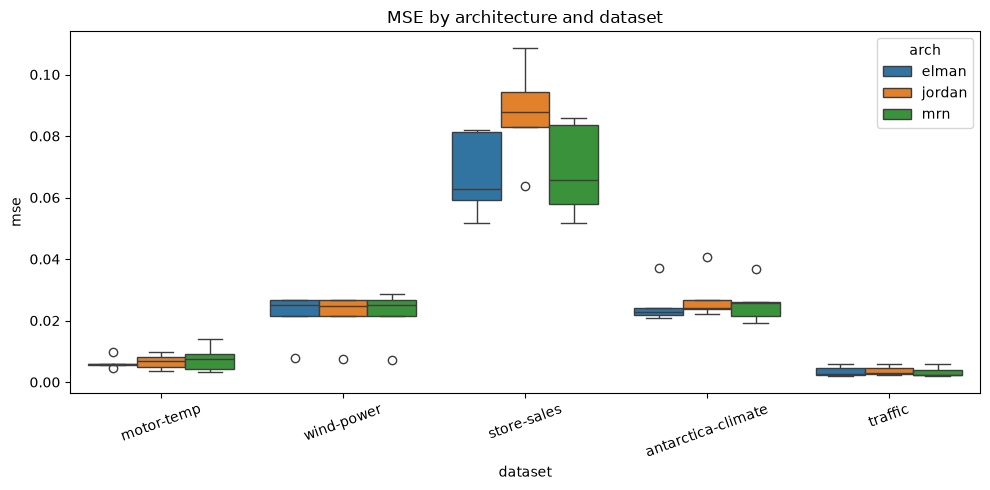

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=results_seasonal_df, x="dataset", y=METRIC, hue="arch", ax=ax)
ax.set_title(f"{METRIC.upper()} by architecture and dataset")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

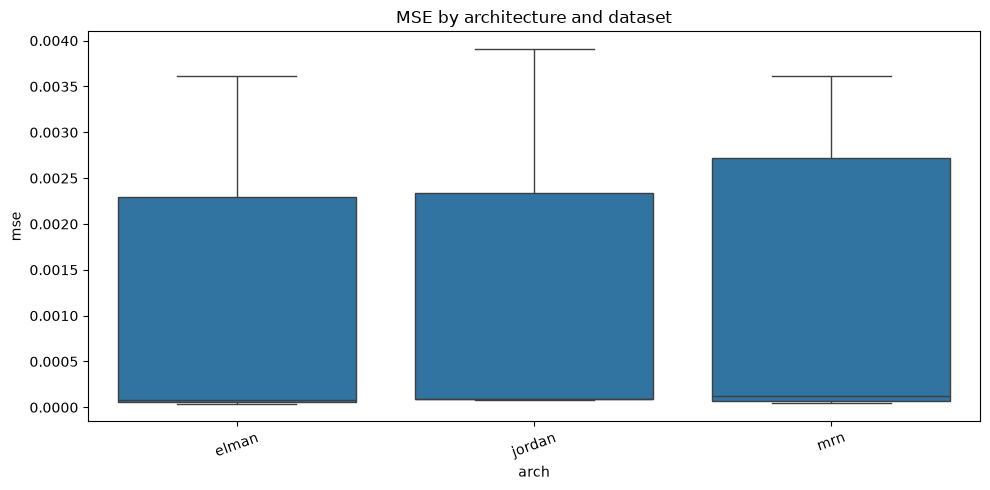

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=results_lopo_df, x="arch", y=METRIC, ax=ax)
ax.set_title(f"{METRIC.upper()} by architecture and dataset")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()